# Undercut Sim — exploration
Clean notebook. Run top to bottom after **Restart Kernel**.

In [7]:
# 0. autoreload — picks up edits to clean.py / loader.py WITHOUT restarting.
# This is the fix for "I edited the file but the notebook still runs the old code".
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root, so `src.*` imports work

from src.data_layer.loader import load_session, get_laps, get_results, get_track_status
from src.data_layer.clean import build_canonical

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# 1. Load the ANCHOR race once. 2019 Hungarian GP — the project anchor.
#    (Use ONE year only. Mixing 2019/2025 in one notebook causes silent wrong-data bugs.)
s = load_session(2025, "Dutch", "R")

core           INFO 	Loading data for Dutch Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '6', '63', '23', '87', '18', '14', '22', '31', '43', '30', '55', '27', '5', '12', '10', '4', '16', '44']


In [9]:
# 2. Build the canonical per-lap table via the FULL pipeline.
#    Always build df this way — never from partial steps — so the flags always exist.
df = build_canonical(get_laps(s), get_results(s), get_track_status(s))

# Guard: confirm we have the real canonical table before trusting anything downstream.
need = ["is_outlap", "is_inlap", "is_sc_vsc", "is_synthetic", "final_position"]
print("all flags present?", all(c in df.columns for c in need))
print("ground truth populated?", df["final_position"].notna().mean())   # near 1.0, not 0
print("rows:", len(df), "| drivers:", df["driver"].nunique())

all flags present? True
ground truth populated? 1.0
rows: 1440 | drivers: 20


In [10]:
# 3. BASE PACE for one driver (HAM) — median of clean green-flag laps.
#    Clean = not an out/in lap, not under SC/VSC, and FastF1 marks it accurate.
#    Drop synthetic rows FIRST — their flag columns are NaN and break the ~ operator.
ham = df[(df["driver"] == "HAM") & ~df["is_synthetic"]]
clean = ham[
    ~ham["is_outlap"] & ~ham["is_inlap"] & ~ham["is_sc_vsc"] & ham["is_accurate"]
]
print("clean laps used:", len(clean))
print("base pace (median):", clean["lap_time"].median())

print(df[["is_outlap","is_inlap","is_sc_vsc","is_synthetic"]].isna().sum())

clean laps used: 21
base pace (median): 0 days 00:01:16.371000
is_outlap       76
is_inlap        76
is_sc_vsc       76
is_synthetic     0
dtype: int64


In [11]:
# 4. BASE PACE for the whole field — one median per driver.
#    Filter out synthetic (invented) rows FIRST — their flag columns are NaN,
#    and you never want ghost laps in a pace calculation anyway.
real = df[~df["is_synthetic"]]
clean_all = real[
    ~real["is_outlap"] & ~real["is_inlap"] & ~real["is_sc_vsc"] & real["is_accurate"]
]
base_pace = clean_all.groupby("driver")["lap_time"].median()
print(base_pace.sort_values())

driver
PIA   0 days 00:01:14.780500
NOR   0 days 00:01:14.794000
VER   0 days 00:01:15.011000
HAD   0 days 00:01:15.121500
ANT   0 days 00:01:15.219500
LEC   0 days 00:01:15.434000
RUS   0 days 00:01:15.747500
ALB   0 days 00:01:15.754500
LAW   0 days 00:01:16.061000
SAI   0 days 00:01:16.116500
STR   0 days 00:01:16.159000
ALO   0 days 00:01:16.194500
HAM   0 days 00:01:16.371000
TSU   0 days 00:01:16.516500
BEA   0 days 00:01:16.542500
COL   0 days 00:01:16.584000
OCO   0 days 00:01:16.694000
GAS   0 days 00:01:16.718000
HUL   0 days 00:01:16.741000
BOR   0 days 00:01:16.809000
Name: lap_time, dtype: timedelta64[ns]


In [12]:
from src.models.pace import base_pace   # adjust path to where you put pace.py
bp = base_pace(df)
print(len(bp), "drivers got a base pace")
print(bp.sort_values())

20 drivers got a base pace
driver
PIA   0 days 00:01:14.780500
NOR   0 days 00:01:14.794000
VER   0 days 00:01:15.011000
HAD   0 days 00:01:15.121500
ANT   0 days 00:01:15.219500
LEC   0 days 00:01:15.434000
RUS   0 days 00:01:15.747500
ALB   0 days 00:01:15.754500
LAW   0 days 00:01:16.061000
SAI   0 days 00:01:16.116500
STR   0 days 00:01:16.159000
ALO   0 days 00:01:16.194500
HAM   0 days 00:01:16.371000
TSU   0 days 00:01:16.516500
BEA   0 days 00:01:16.542500
COL   0 days 00:01:16.584000
OCO   0 days 00:01:16.694000
GAS   0 days 00:01:16.718000
HUL   0 days 00:01:16.741000
BOR   0 days 00:01:16.809000
Name: lap_time, dtype: timedelta64[ns]


In [13]:
from src.models.fuel import fuel_remaining, fuel_effect

print(fuel_remaining(1, 70))    # ≈ 110  (full at start)
print(fuel_remaining(70, 70))   # ≈ 1.6  (near empty at the end)
print(fuel_effect(1, 70))       # POSITIVE — heavy early, slower than mid-race ref
print(fuel_effect(35, 70))      # ≈ 0     — at the reference, correction vanishes
print(fuel_effect(70, 70))      # NEGATIVE — light late, faster than ref

110.0
1.5714285714285694
1.8700000000000003
0.0
-1.9250000000000003


In [25]:
from src.models.fuel import make_fuel_effect
from src.models.tyre_deg import calculate_degradation, compute_reference_age, deg_effect

total_laps = int(df["lap_number"].max())
fuel_fn = make_fuel_effect(total_laps)

real = df[~df["is_synthetic"]]
clean = real[
    ~real["is_outlap"] & ~real["is_inlap"] & ~real["is_sc_vsc"] & real["is_accurate"]
]

for comp, fb in [("SOFT", 0.10), ("MEDIUM", 0.05), ("HARD", 0.02)]:
    rate = calculate_degradation(clean[clean["compound"] == comp], comp, fb, fuel_fn)
    print(f"{comp}: {rate:.4f} s/lap")

print("reference ages:", compute_reference_age(clean))

# How many stints and how many laps per compound? (is soft just short stints?)
for comp in ["SOFT", "MEDIUM", "HARD"]:
    sub = clean[clean["compound"] == comp]
    print(comp, "| stints:", sub.groupby(["driver","stint"]).ngroups,
          "| total clean laps:", len(sub))
    
    # Are stints grouped per-driver, or are stint numbers colliding across drivers?
print(clean[clean["compound"]=="SOFT"].groupby(["driver","stint"]).ngroups, "true driver-stints")
print(clean[clean["compound"]=="SOFT"].groupby("stint").ngroups, "if grouped by stint alone")

for comp, fb in [("SOFT", 0.10), ("MEDIUM", 0.05), ("HARD", 0.02)]:
    rate = calculate_degradation(clean[clean["compound"] == comp], comp, fb, fuel_fn)
    print(f"{comp}: {rate:.4f} s/lap")

SOFT | ALB stint 3.0 | n=11 | slope=0.0311
SOFT | ANT stint 4.0 | n=11 | slope=0.0294
SOFT | BOR stint 3.0 | n=7 | slope=0.3160
SOFT | COL stint 1.0 | n=17 | slope=0.0887
SOFT | HAD stint 3.0 | n=11 | slope=0.0160
SOFT | HUL stint 1.0 | n=17 | slope=0.0662
SOFT | LAW stint 3.0 | n=21 | slope=0.0743
SOFT | LAW stint 4.0 | n=11 | slope=0.1958
SOFT | RUS stint 3.0 | n=11 | slope=0.0364
SOFT | SAI stint 3.0 | n=20 | slope=0.0919
SOFT | SAI stint 4.0 | n=7 | slope=0.2405
SOFT | TSU stint 1.0 | n=17 | slope=0.0615
SOFT | TSU stint 3.0 | n=11 | slope=-0.0193
SOFT | VER stint 1.0 | n=21 | slope=0.0854
SOFT | VER stint 3.0 | n=11 | slope=0.0016
SOFT: 0.0877 s/lap
MEDIUM | ALB stint 1.0 | n=21 | slope=0.0386
MEDIUM | ALO stint 1.0 | n=16 | slope=0.0544
MEDIUM | ANT stint 1.0 | n=21 | slope=0.0473
MEDIUM | BEA stint 2.0 | n=11 | slope=-0.0395
MEDIUM | BOR stint 1.0 | n=20 | slope=0.0555
MEDIUM | COL stint 3.0 | n=7 | slope=-0.1100
MEDIUM | GAS stint 1.0 | n=21 | slope=0.0574
MEDIUM | HAD stint 1.

In [24]:
from src.models.pace import base_pace, predicted_lap_time
from src.models.fuel import make_fuel_effect
from src.models.tyre_deg import calculate_degradation, compute_reference_age, deg_effect
# Build the precomputed pieces once
bp = base_pace(df)
ref_age = compute_reference_age(clean)
deg_rates = {
    comp: calculate_degradation(clean[clean["compound"] == comp], comp, fb, fuel_fn)
    for comp, fb in [("SOFT", 0.10), ("MEDIUM", 0.05), ("HARD", 0.02)]
}

# Pick a real HAM lap mid-race and compare predicted vs actual
real = df[~df["is_synthetic"]]
ham = real[(real["driver"] == "HAM") & ~real["is_outlap"] & ~real["is_inlap"]
           & ~real["is_sc_vsc"] & real["is_accurate"]]

for _, row in ham.iloc[::1].iterrows():   # every 10th clean lap
    pred = predicted_lap_time(
        "HAM", row["lap_number"], row["tyre_age"], row["compound"],
        bp, fuel_fn, deg_rates, ref_age
    )
    actual = row["lap_time"].total_seconds()
    print(f"lap {int(row['lap_number']):2d} | pred {pred:.3f} | actual {actual:.3f} | err {pred-actual:+.3f}")

SOFT | ALB stint 3.0 | n=11 | slope=0.0311
SOFT | ANT stint 4.0 | n=11 | slope=0.0294
SOFT | BOR stint 3.0 | n=7 | slope=0.3160
SOFT | COL stint 1.0 | n=17 | slope=0.0887
SOFT | HAD stint 3.0 | n=11 | slope=0.0160
SOFT | HUL stint 1.0 | n=17 | slope=0.0662
SOFT | LAW stint 3.0 | n=21 | slope=0.0743
SOFT | LAW stint 4.0 | n=11 | slope=0.1958
SOFT | RUS stint 3.0 | n=11 | slope=0.0364
SOFT | SAI stint 3.0 | n=20 | slope=0.0919
SOFT | SAI stint 4.0 | n=7 | slope=0.2405
SOFT | TSU stint 1.0 | n=17 | slope=0.0615
SOFT | TSU stint 3.0 | n=11 | slope=-0.0193
SOFT | VER stint 1.0 | n=21 | slope=0.0854
SOFT | VER stint 3.0 | n=11 | slope=0.0016
MEDIUM | ALB stint 1.0 | n=21 | slope=0.0386
MEDIUM | ALO stint 1.0 | n=16 | slope=0.0544
MEDIUM | ANT stint 1.0 | n=21 | slope=0.0473
MEDIUM | BEA stint 2.0 | n=11 | slope=-0.0395
MEDIUM | BOR stint 1.0 | n=20 | slope=0.0555
MEDIUM | COL stint 3.0 | n=7 | slope=-0.1100
MEDIUM | GAS stint 1.0 | n=21 | slope=0.0574
MEDIUM | HAD stint 1.0 | n=21 | slope=0.

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root, so `src` is importable

from src.sim.forward import RaceConstants, CarState, advance_one_lap
static = RaceConstants(bp, fuel_fn, deg_rates, ref_age)
car = CarState("HAM", lap_number=30, tyre_age=15, compound="MEDIUM",
               cumulative_time=0.0, pit_lap=32, next_compound="HARD")

for _ in range(5):
    car = advance_one_lap(car, static, pit_loss=22.0)
    print(car.lap_number, car.tyre_age, car.compound, round(car.cumulative_time, 2))

31 16 MEDIUM 76.83
32 17 MEDIUM 153.63
33 0 HARD 252.42
34 1 HARD 328.17
35 2 HARD 403.9


In [27]:
import sys
from src.sim.undercut import undercut_verdict
from src.sim.forward import CarState
# my driver chasing a rival ~1.5s ahead, both on old mediums, ~20 laps left
hadjar = CarState("HAD", lap_number=40, tyre_age=18, compound="MEDIUM",
                      cumulative_time=2.0, next_compound="HARD")   # 2s behind P3
rival_ahead = CarState("VER", lap_number=40, tyre_age=18, compound="MEDIUM",
                           cumulative_time=0.0, next_compound="HARD")

verdict = undercut_verdict(hadjar, rival_ahead, static, pit_loss=22.0, n_laps=20)
print(verdict)
verdict = undercut_verdict(hadjar, rival_ahead, static, pit_loss=22.0, n_laps=5)
print(verdict)

UndercutVerdict(works=np.False_, time_delta=np.float64(-3.221857800238695), gap_after_pit=np.float64(7.431857800238731), gap_after_stay_out=np.float64(4.210000000000036))
UndercutVerdict(works=np.False_, time_delta=np.float64(-17.821521181310004), gap_after_pit=np.float64(20.374021181310013), gap_after_stay_out=np.float64(2.552500000000009))


SOFT | ALB stint 3.0 | n=11 | slope=0.0311
SOFT | ANT stint 4.0 | n=11 | slope=0.0294
SOFT | BOR stint 3.0 | n=7 | slope=0.3160
SOFT | COL stint 1.0 | n=17 | slope=0.0887
SOFT | HAD stint 3.0 | n=11 | slope=0.0160
SOFT | HUL stint 1.0 | n=17 | slope=0.0662
SOFT | LAW stint 3.0 | n=21 | slope=0.0743
SOFT | LAW stint 4.0 | n=11 | slope=0.1958
SOFT | RUS stint 3.0 | n=11 | slope=0.0364
SOFT | SAI stint 3.0 | n=20 | slope=0.0919
SOFT | SAI stint 4.0 | n=7 | slope=0.2405
SOFT | TSU stint 1.0 | n=17 | slope=0.0615
SOFT | TSU stint 3.0 | n=11 | slope=-0.0193
SOFT | VER stint 1.0 | n=21 | slope=0.0854
SOFT | VER stint 3.0 | n=11 | slope=0.0016
MEDIUM | ALB stint 1.0 | n=21 | slope=0.0386
MEDIUM | ALO stint 1.0 | n=16 | slope=0.0544
MEDIUM | ANT stint 1.0 | n=21 | slope=0.0473
MEDIUM | BEA stint 2.0 | n=11 | slope=-0.0395
MEDIUM | BOR stint 1.0 | n=20 | slope=0.0555
MEDIUM | COL stint 3.0 | n=7 | slope=-0.1100
MEDIUM | GAS stint 1.0 | n=21 | slope=0.0574
MEDIUM | HAD stint 1.0 | n=21 | slope=0.

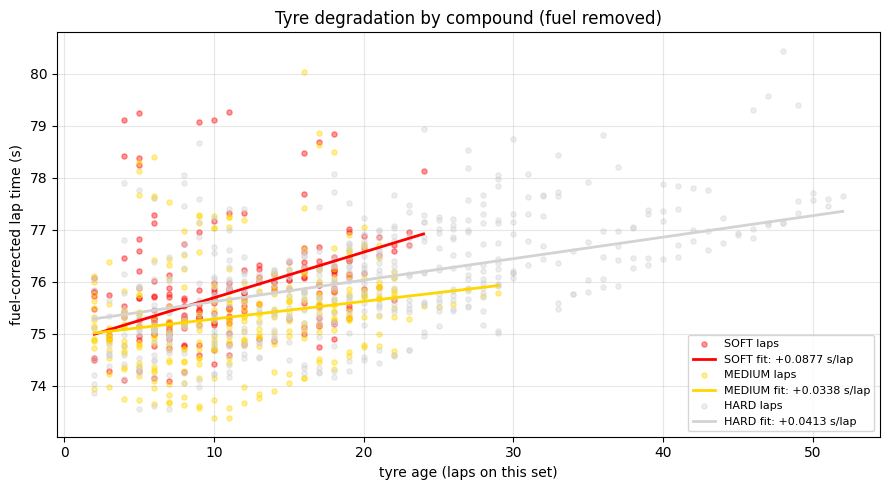

In [26]:
# Visualize the degradation pattern: fuel-corrected lap time vs tyre age, per compound.
# Scatter = real clean laps (fuel removed). Line = the fitted deg slope that
# calculate_degradation() returns, anchored at that compound's reference age.
import matplotlib.pyplot as plt
import numpy as np

# Build the pieces locally so this cell runs standalone after the cell above.
deg_rates = {
    comp: calculate_degradation(clean[clean["compound"] == comp], comp, fb, fuel_fn)
    for comp, fb in [("SOFT", 0.10), ("MEDIUM", 0.05), ("HARD", 0.02)]
}
ref_age = compute_reference_age(clean)

def plot_degradation(clean, deg_rates, ref_age, fuel_fn):
    colors = {"SOFT": "red", "MEDIUM": "gold", "HARD": "lightgrey"}
    fig, ax = plt.subplots(figsize=(9, 5))

    for comp in ["SOFT", "MEDIUM", "HARD"]:
        sub = clean[clean["compound"] == comp]
        if sub.empty:
            continue

        # fuel-correct each lap (same step calculate_degradation does internally)
        x = sub["tyre_age"].to_numpy(dtype=float)
        y = (sub["lap_time"].dt.total_seconds()
             - sub["lap_number"].map(fuel_fn)).to_numpy(dtype=float)

        ax.scatter(x, y, s=14, alpha=0.4, color=colors[comp], label=f"{comp} laps")

        # overlay the fitted deg line: slope = rate, zero correction at ref age.
        rate = deg_rates[comp]
        ra = ref_age[comp]
        xs = np.linspace(x.min(), x.max(), 50)
        # anchor the line at the median fuel-corrected time at the reference age
        intercept = np.median(y) - rate * (np.median(x) - ra)
        ax.plot(xs, intercept + rate * (xs - ra), color=colors[comp], lw=2,
                label=f"{comp} fit: {rate:+.4f} s/lap")

    ax.set_xlabel("tyre age (laps on this set)")
    ax.set_ylabel("fuel-corrected lap time (s)")
    ax.set_title("Tyre degradation by compound (fuel removed)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_degradation(clean, deg_rates, ref_age, fuel_fn)